# Adding a function to aether

> Add your own maths function that runs on CPU and GPU, without editing
> aether.

**Time:** ~6 min · **Runs on:** CPU · **You need:**
[Device math](03_device_math)

In [1]:
%run ../_shared/setup.py

running on: cpu


Every `aether::math` entry point is built from one macro,
`AETHER_MATH_UNARY`. Here is the whole of `erf`/`erfc`, two lines
total:

```cpp
AETHER_MATH_UNARY(erf, erff, ::erf, std::erf(x))
AETHER_MATH_UNARY(erfc, erfcf, ::erfc, std::erfc(x))
```

`NAME` is the function name; `FLOATFN`/`DOUBLEFN` are the *device-pass*
callables (what runs when this file is built as CUDA); `STDEXPR` is the
*host-pass* expression (what runs otherwise).

The cell below adds `cot` (cotangent, `1/tan`) the same way.
`AETHER_FORCEINLINE()` asks the compiler to always inline the tiny
wrapper rather than emit a real call -- one overload for `float`, one
for `double`, matching the macro's own two legs:

`aether/math/detail/MathDispatch.h` is the macro's own home -- the
exact header aether's own `special.h` includes to build `erf`/`erfc` --
and `MathDispatchUndef.h` closes its scope right after, the same way
every real facade header in `aether/math/` does.

The two helpers below are plain free functions, named `cotFloat`/
`cotDouble` in aether's own camelCase convention for a helper like
this:

In [2]:
COT_SCAFFOLD = r"""
    #include "aether/math/detail/MathDispatch.h"

    AETHER_DEVICEHOST() AETHER_FORCEINLINE() float cotFloat(float x) { return 1.0f / ::tanf(x); }
    AETHER_DEVICEHOST() AETHER_FORCEINLINE() double cotDouble(double x) { return 1.0 / ::tan(x); }

    namespace my_contrib {
    AETHER_MATH_UNARY(cot, cotFloat, cotDouble, 1.0 / std::tan(x))
    }

    #include "aether/math/detail/MathDispatchUndef.h"
"""
print("COT_SCAFFOLD defined -- one new free function, ready to call.")

COT_SCAFFOLD defined -- one new free function, ready to call.


In [3]:
print(run_cpp(r"""
    std::printf("cot(1.0f) = %.6f   cot(1.0) = %.6f\n",
                 my_contrib::cot(1.0f), my_contrib::cot(1.0));
""", top=COT_SCAFFOLD, includes=("<cmath>",)))

cot(1.0f) = 0.642093   cot(1.0) = 0.642093



Both overloads agree with `1/tan(x)` computed by hand -- the macro is
templated on `float`/`double`, dispatching to whichever this call needs.

## What you will build (the picture)

A sweep of the new function, using the same scaffold defined above:

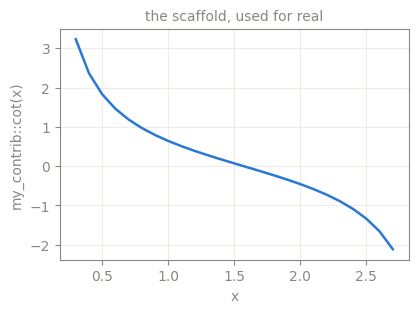

In [4]:
import matplotlib.pyplot as plt
plot_style()

out = run_cpp(r"""
    for (double x = 0.3; x <= 2.8; x += 0.1)
        std::printf("D,%.4f,%.6f\n", x, my_contrib::cot(x));
""", top=COT_SCAFFOLD, includes=("<cmath>",))
_, sweep_rows = split_data(out)
xs = [float(r[0]) for r in sweep_rows]
ys = [float(r[1]) for r in sweep_rows]

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(xs, ys, color="#2a78d6", lw=1.8)
ax.set_xlabel("x"); ax.set_ylabel("my_contrib::cot(x)")
ax.set_title("the scaffold, used for real", color="#898781", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## What just happened

- `AETHER_MATH_UNARY(NAME, FLOATFN, DOUBLEFN, STDEXPR)` is the whole
  scaffold aether's own `erf`/`erfc` use.
- The demo above adds a genuinely new function (`cot`) with zero edits to
  aether's own headers -- proof the mechanism is just a macro.
- `aether/math/detail/MathDispatch.h` is a `detail/` header; the
  include/define/undef cycle around it is the same way every real
  facade header in `aether/math/` is written.

## Try this

Add a second trig identity, `coth(x) = 1/tanh(x)`, using the same
`cotFloat`/`cotDouble`/`AETHER_MATH_UNARY` pattern.

## Next

This is the last tutorial in the aether path. [hawk's vocabulary
tutorials](https://amasat01.github.io/hawk/content/vocabulary.html) pick
up from here if you want to write kernels that call into aether; *deeper:*
[aether/math/detail/MathDispatch.h](../api/api_reference.rst) in the API
reference for the macro's full definition.

## Going deeper (optional): landing it for real

The banded (`BandedReal`) companion macros are a separate, certified
extension that widens five entry points (`abs`, `copysign`, `fmax`,
`fmin`, `pow`) to accept aether's emulated-double type -- out of scope
for a brand-new function like `cot` above.

This tutorial proves the *mechanism*, not a shipped function: `cot`
above lives only in this notebook's temp file. Landing it for real --
so it ships as `aether::math::cot` for every consumer, with the banded
companion and the accuracy sweep its neighbours get -- means the same
two lines inside `aether/math/*.h` itself, as a pull request.

A new `aether::math` function is only half the path to a hawk kernel
calling it: hawk needs to know the op exists, how to spell it in
generated code, and what its derivative is. hawk's own contributor
guide, [Add a native function end to
end](https://amasat01.github.io/hawk/content/vocabulary/add_a_native_function.html),
picks up exactly where this tutorial stops -- its own step 1 is the same
`AETHER_MATH_UNARY` line this tutorial just ran.